The following example shows how to train a model. Get a list of training data csv file in the selected folder. Lessons learned so far:
- Training result is very sensitive to normalization. The normalization approach based on mean and variance does not work very well. Still need to manually set mean and variance.
- t-sne plot of adapter trace is an important flag of training result. 
- h net does not have to descent because phi net training strives to make it rise, while h net training itself tries to lower the loss
- Increase the h training frequency to fight against rising h 
- Increase alpha to push domain info to adapter
- Increase number of features to minimize MSE loss.
- ocassional small spike in cross entropy loss is possibly a sign that phi net become further domain invariant and may not be bad.
- at the late stage of training while both mse loss and cross entropy loss converge. May need to train h net every step to refine the optimization direction.
- Do not need to select the model at the end epoch. Select the epoch when the loss is reasonably low and stable. 
- RMS is a good indicator because it matches the least square form of loss function
- When the residual force is small, e.g. training disturbance force compensated by BEMT, disturbance normalization should scale up the label for better learning. 

Existing problem:
- The more classes, the harder to train. The difficulty comes from instability of loss_f and loss_c. alpha is hard to tune.
- t-sne gets worse as epoch grows and the cross entropy loss remains the same. 

In [1]:
import os
import matplotlib.pyplot as plt

import training_manager

current_dir = os.getcwd()
# training_subfolder = "wind_near_wall_wo_bemt_in_control_train_xz_wind"
# training_subfolder = "wind_near_wall_wo_bemt_in_control_far_from_wall"  # training in no wall condition
# training_subfolder = "nf_training_back2back"
# training_subfolder = "wind_free_space_training_diaml"
training_subfolder = "wind_free_space_training_in_house_sim_diaml"
# validation_subfolder = "nf_validation_back2back"
# validation_subfolder = "wind_near_wall_validation_no_bemt"
# validation_subfolder = "wind_near_wall_validation_no_bemt_sinusoidal"
# validation_subfolder = "wind_free_space_validation_diaml"
validation_subfolder = "wind_free_space_validation_in_house_sim_diaml"

def generate_data_list(subfolder):
    """
    Generate a list of data files in the specified subfolder.
    """
    folder_path = os.path.join(os.path.dirname(current_dir), "data", "training", subfolder)
    file_names = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

    # Filter out files that do not end with .csv
    file_names = [f for f in file_names if f.endswith('.csv')]
    # add subfolder to the file names
    data_list = [os.path.join(subfolder, f) for f in file_names]
    return data_list

data_list = generate_data_list(training_subfolder)
print("Training Data List:")
for data in data_list:
    print(data)

validation_list = generate_data_list(validation_subfolder)
print("\nValidation Data List:")
for data in validation_list:
    print(data)

path1 = os.path.join(training_subfolder, "input_label_map_disturbance_force_label.yaml")

Training Data List:
wind_free_space_training_in_house_sim_diaml\test_wind_near_wall_x0_0_y0_0_z0_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim_diaml\test_wind_near_wall_x0_0_y0_0_z3_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim_diaml\test_wind_near_wall_x0_0_y0_0_z5_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim_diaml\test_wind_near_wall_x0_0_y0_0_zn3_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim_diaml\test_wind_near_wall_x0_0_y0_0_zn5_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim_diaml\test_wind_near_wall_xn1_0_y0_0_z0_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim_diaml\test_wind_near_wall_xn1_0_y0_0_z3_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim_diaml\test_wind_near_wall_xn1_0_y0_0_z5_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim_diaml\test_wind_near_wall_xn1_0_y0_0_zn3_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim

- Make sure the input_label_map_disturbance_force_label.yaml is in the selected folder. This yaml defines which fields are model inputs and which fields are data labels. 
- Make sure the column_map.yaml is in the selected folder. This yaml maps data fields to the corresponding column in the csv files. This file can be auto-generated by `Simulation\simulation\training_data_user_guide.ipynb`
- If this is the first time to train on this data. The script will normalize the data and save the normalization parameters into a file.

Setting up data factory...
Loading normalization params file from
..\data\training\wind_free_space_training_in_house_sim_diaml\normalization_params.yaml
Using 2002 samples from the dataset for training from source file: wind_free_space_training_in_house_sim_diaml\test_wind_near_wall_x0_0_y0_0_z0_0_d100_4_train_no_bemt.csv
Using 2002 samples from the dataset for training from source file: wind_free_space_training_in_house_sim_diaml\test_wind_near_wall_x0_0_y0_0_z3_0_d100_4_train_no_bemt.csv
Using 2002 samples from the dataset for training from source file: wind_free_space_training_in_house_sim_diaml\test_wind_near_wall_x0_0_y0_0_z5_0_d100_4_train_no_bemt.csv
Using 2002 samples from the dataset for training from source file: wind_free_space_training_in_house_sim_diaml\test_wind_near_wall_x0_0_y0_0_zn3_0_d100_4_train_no_bemt.csv
Using 2002 samples from the dataset for training from source file: wind_free_space_training_in_house_sim_diaml\test_wind_near_wall_x0_0_y0_0_zn5_0_d100_4_train_no

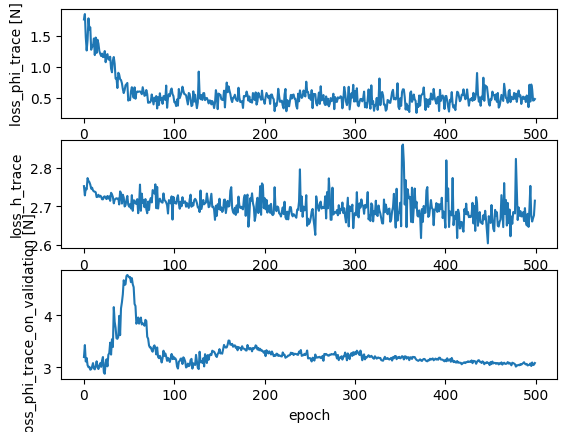

In [2]:
# use the data from previous section to train the model

factory = training_manager.PipelineFactory(training_manager.ModelArchitecture.DIAML)
manager = factory.make_training_pipeline()
manager.set_up(
    training_data_menu=data_list,
    # training_data_menu=data_list[:4],    # use small data list for quick testing
    validation_data_menu=validation_list[-1:],
    input_label_map_file=path1,
    can_inspect_data=False
)
plt.show() 
manager.train()

plt.show()  

Inspect data in the data list.

Plotting t-SNE of a_trace...


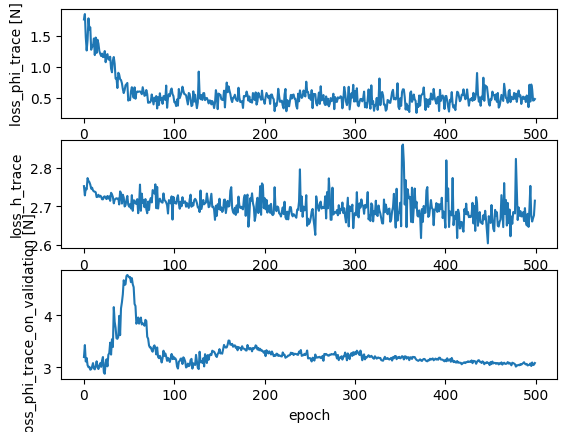

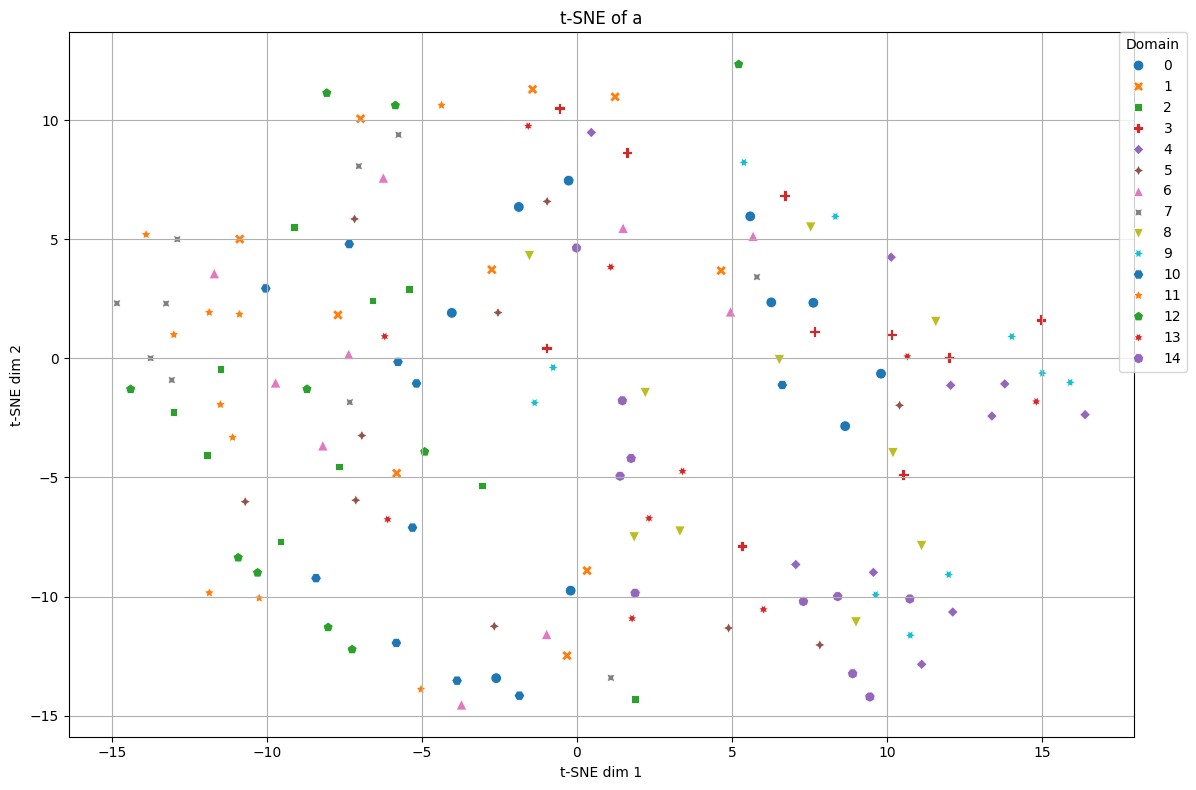

In [3]:
# trainer_instance.inspect_data(data_list[:2])
manager.show_result_only()

After training, we can save the model in the following way.

In [4]:
model_name = training_subfolder
manager.save_model(model_name)

Model saved to model\wind_free_space_training_in_house_sim_diaml.pth


Test the model using the test set.

test Data List:
wind_free_space_validation_diaml\test_wind_near_wall_x0_0_y0_0_z1_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_diaml\test_wind_near_wall_x0_0_y0_0_z4_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_diaml\test_wind_near_wall_x0_0_y0_0_zn1_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_diaml\test_wind_near_wall_x0_0_y0_0_zn4_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_diaml\test_wind_near_wall_xn2_0_y0_0_z1_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_diaml\test_wind_near_wall_xn2_0_y0_0_z4_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_diaml\test_wind_near_wall_xn2_0_y0_0_zn1_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_diaml\test_wind_near_wall_xn2_0_y0_0_zn4_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_diaml\test_wind_near_wall_xn5_0_y0_0_z1_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_diaml\test_wind_near_wall_xn5_0_y0_0_z4_0_d1_4_validation_no_bemt.csv
wind_free_spac

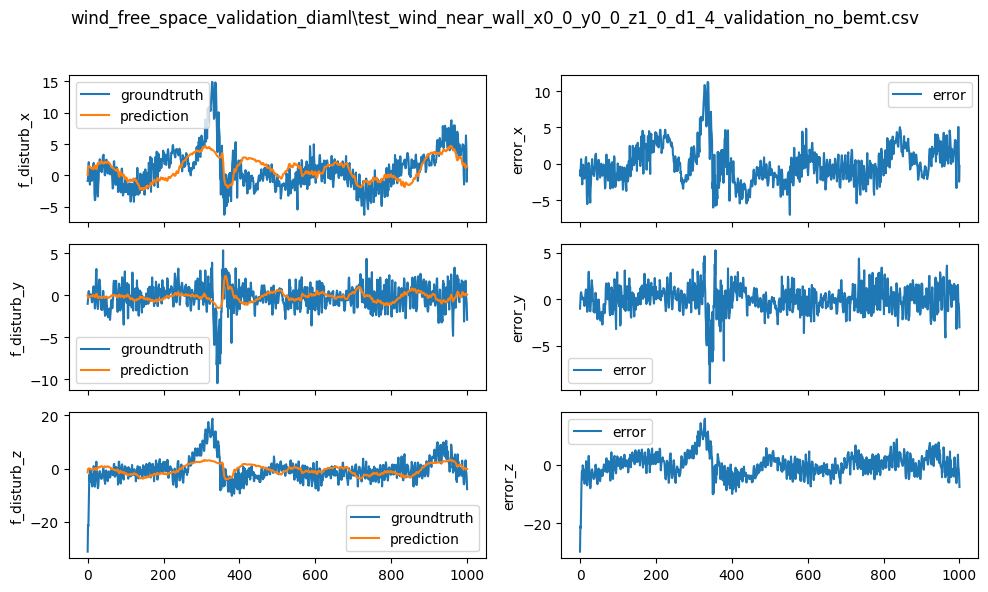

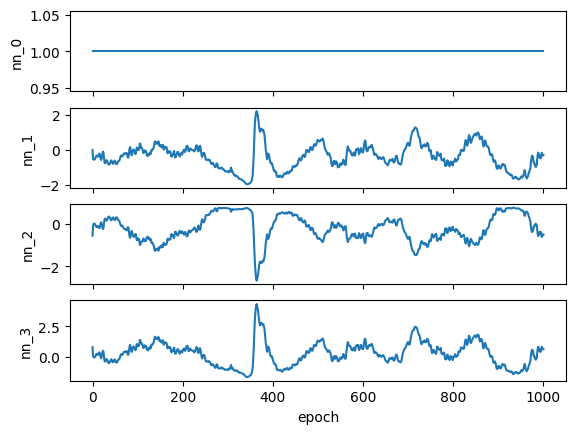

phi_out: tensor([[ 1.0000, -0.0064, -0.5518,  0.7686],
        [ 1.0000, -0.5336, -0.0805,  0.0147],
        [ 1.0000, -0.5346, -0.0301, -0.0283],
        ...,
        [ 1.0000, -0.7171,  0.0153, -0.0121],
        [ 1.0000, -0.7837,  0.0689, -0.1018],
        [ 1.0000, -0.9071,  0.1564, -0.2601]])
a = tensor([[ 3.2139,  1.2079, -0.0159],
        [ 4.2337,  1.8804,  4.8340],
        [-1.8411,  0.9312, -1.2149],
        [-4.4773, -0.5086, -3.7765]])


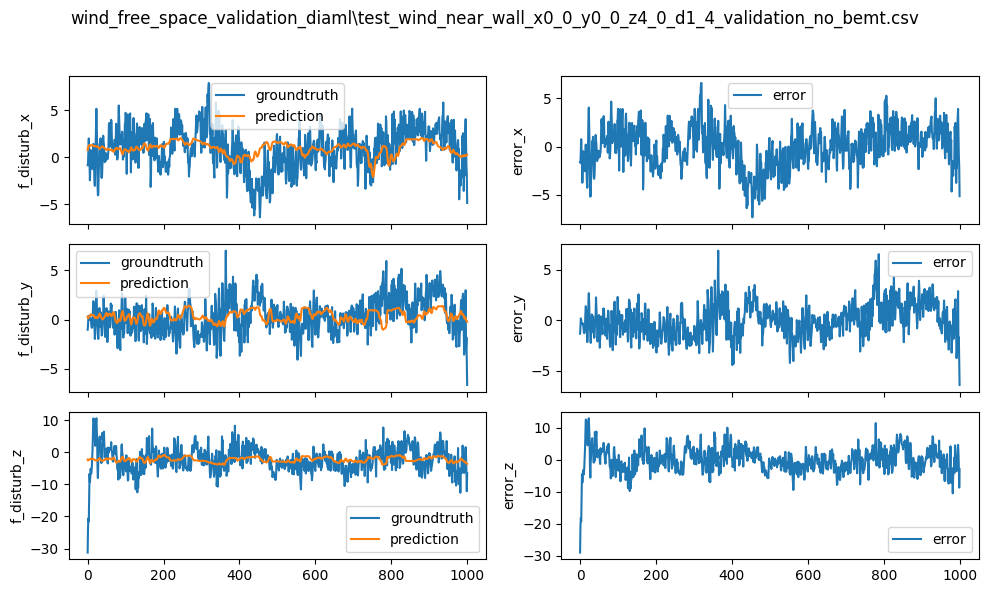

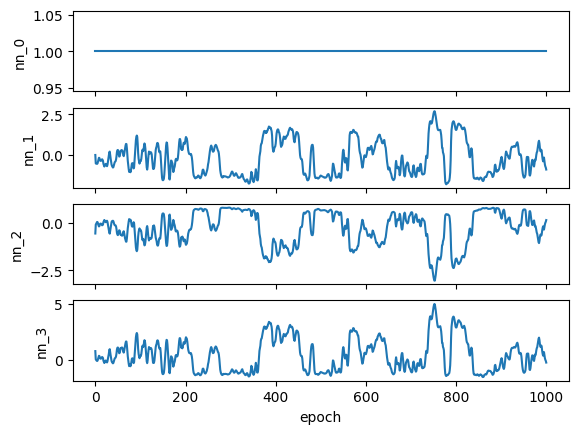

phi_out: tensor([[ 1.0000, -0.0035, -0.5533,  0.7737],
        [ 1.0000, -0.5028, -0.1198,  0.0760],
        [ 1.0000, -0.5427, -0.0463, -0.0116],
        ...,
        [ 1.0000, -0.8382, -0.0960, -0.0751],
        [ 1.0000, -1.1062,  0.0858, -0.4269],
        [ 1.0000, -1.1538,  0.1238, -0.4924]])
a = tensor([[ -1.8813,  -0.4402,  -4.8320],
        [ -6.1525,  -0.8776, -10.2138],
        [  6.3703,   2.8378,  17.7571],
        [  6.6644,   2.6480,  18.9112]])


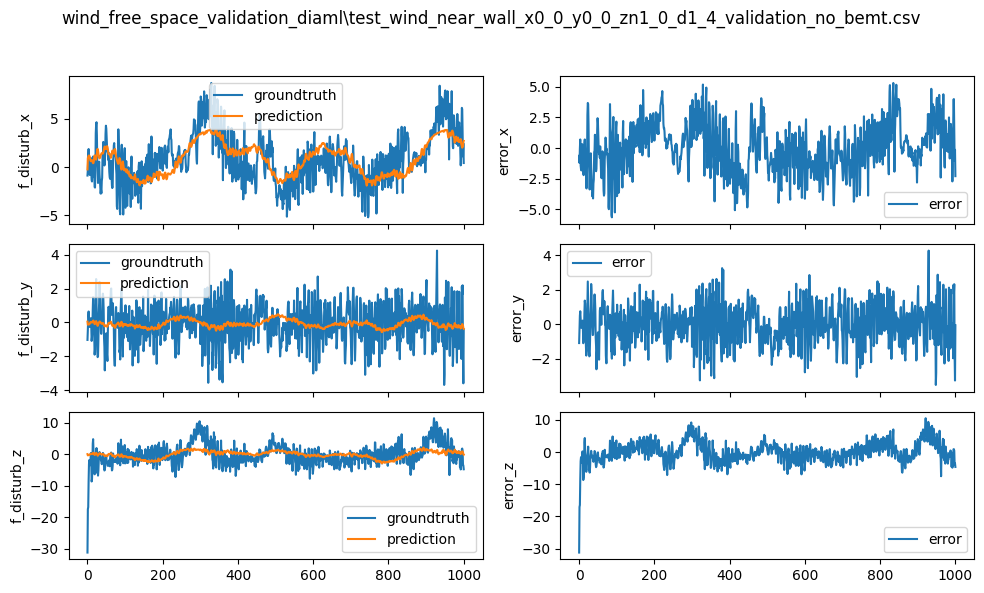

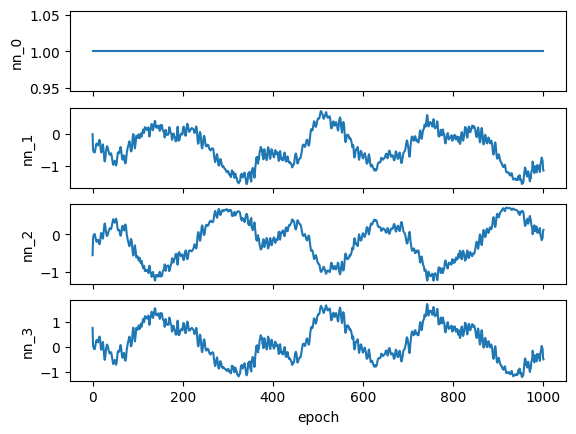

phi_out: tensor([[ 1.0000,  0.0035, -0.5578,  0.7834],
        [ 1.0000, -0.4654, -0.1719,  0.1523],
        [ 1.0000, -0.5301, -0.1107,  0.0608],
        ...,
        [ 1.0000, -0.9663, -0.0676, -0.1999],
        [ 1.0000, -1.0766,  0.0174, -0.3490],
        [ 1.0000, -1.2146,  0.1152, -0.5331]])
a = tensor([[ -9.4068,  -2.7343,   2.0155],
        [-19.3305,  -5.2148,  -5.2348],
        [ 18.8998,   7.7788,  18.4428],
        [ 24.7170,   9.4581,  17.4221]])


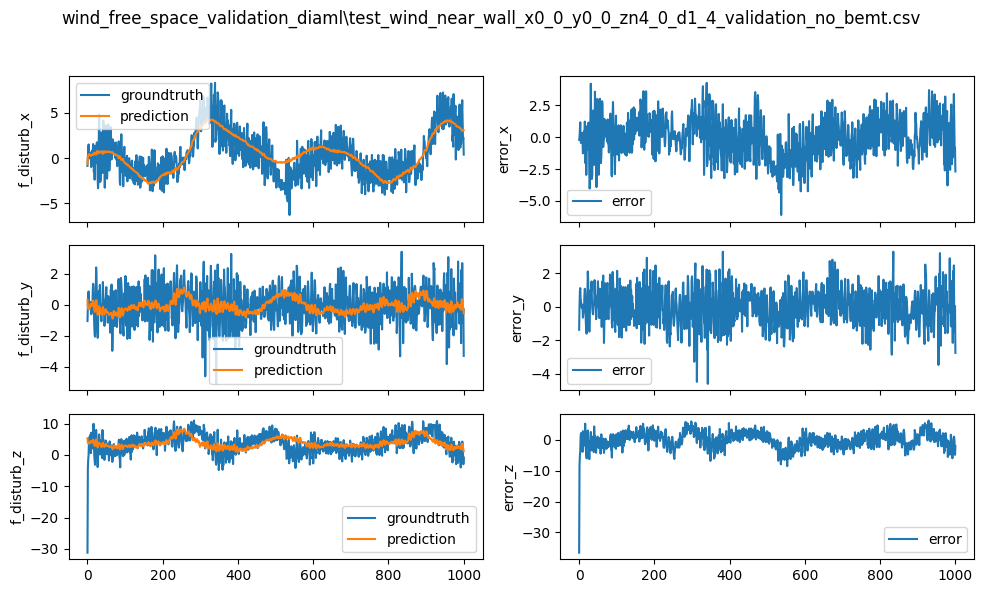

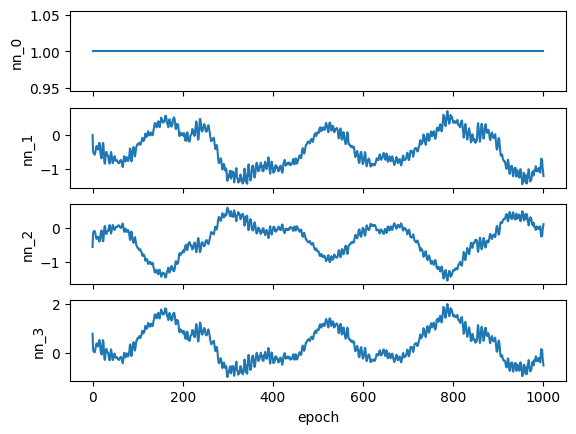

phi_out: tensor([[ 1.0000,  0.0024, -0.5563,  0.7805],
        [ 1.0000,  0.3337, -0.7645,  1.1789],
        [ 1.0000,  0.4063, -0.7717,  1.2339],
        ...,
        [ 1.0000,  0.3095, -1.1562,  1.5921],
        [ 1.0000,  0.0147, -0.9507,  1.2019],
        [ 1.0000, -0.2051, -0.7902,  0.9067]])
a = tensor([[ -5.8707,  -0.6375,  -8.4231],
        [-10.5390,  -0.3525, -14.5473],
        [ 16.8358,   4.2423,  19.2315],
        [ 16.8510,   3.1414,  21.9941]])


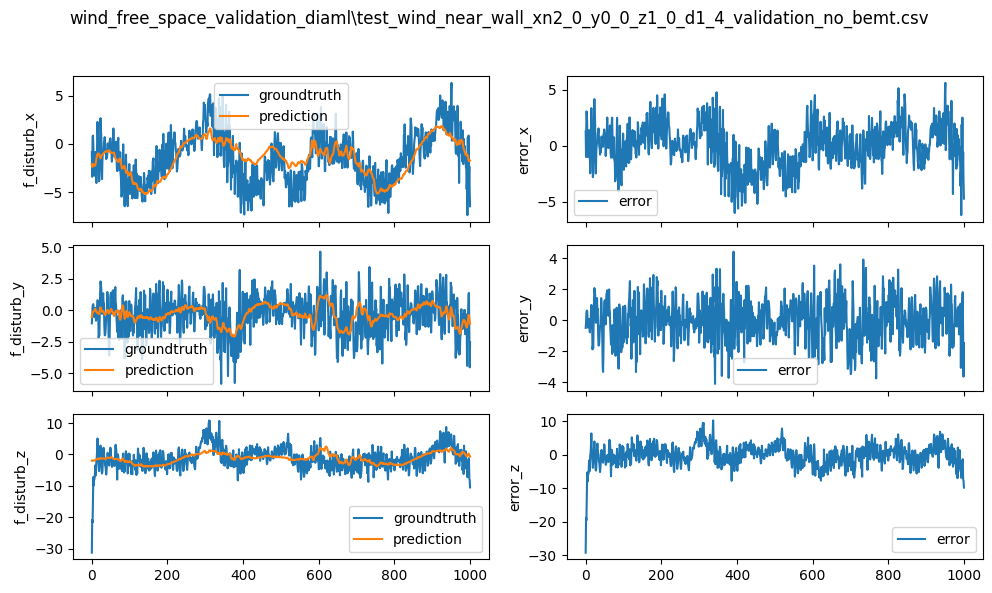

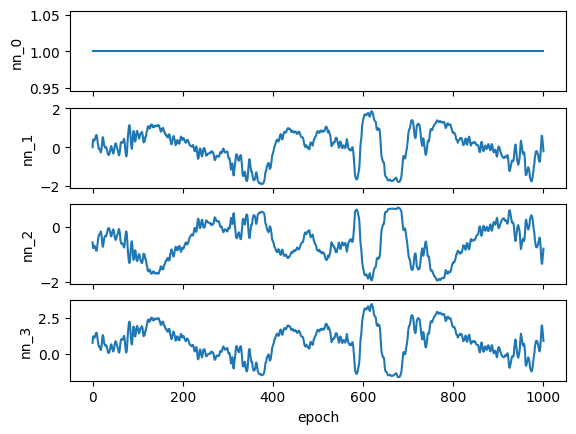

phi_out: tensor([[ 1.0000, -0.0035, -0.5527,  0.7722],
        [ 1.0000,  0.2650, -0.7025,  1.0765],
        [ 1.0000,  0.3778, -0.7408,  1.1845],
        ...,
        [ 1.0000, -1.6024,  0.3699, -1.0186],
        [ 1.0000, -1.3685,  0.1944, -0.6926],
        [ 1.0000, -0.8914, -0.1376, -0.0587]])
a = tensor([[ -0.2560,   0.2898, -19.8608],
        [ -0.8189,   1.6366, -31.0921],
        [  4.4222,   0.9794,  28.4706],
        [  2.8486,  -0.2522,  38.6958]])


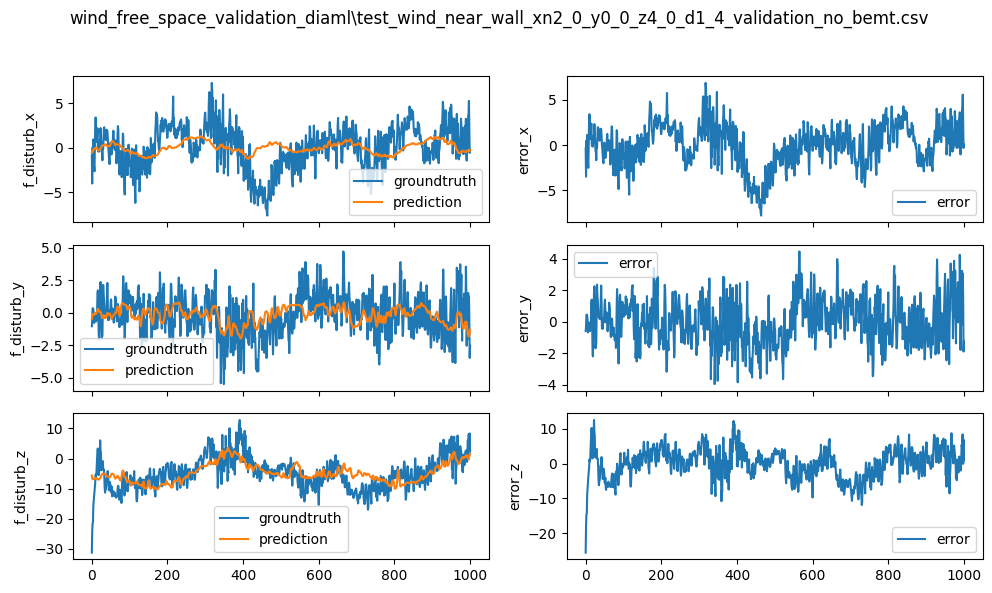

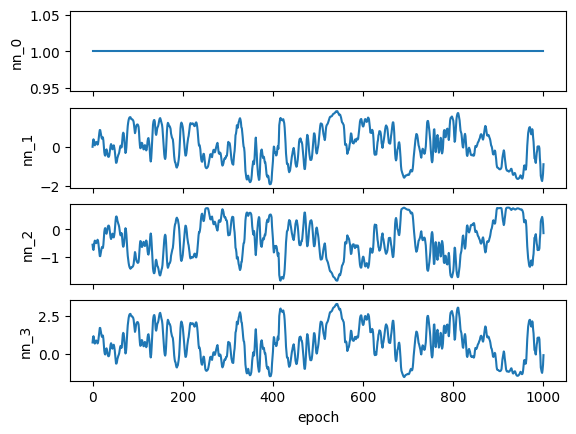

phi_out: tensor([[ 1.0000e+00, -7.7102e-04, -5.5373e-01,  7.7691e-01],
        [ 1.0000e+00,  3.5946e-01, -7.9120e-01,  1.2221e+00],
        [ 1.0000e+00,  4.3544e-01, -8.1150e-01,  1.2910e+00],
        ...,
        [ 1.0000e+00, -5.6952e-01, -3.3567e-01,  3.1042e-01],
        [ 1.0000e+00, -7.0666e-01, -2.3467e-01,  1.2567e-01],
        [ 1.0000e+00, -7.4659e-01, -2.0618e-01,  7.0312e-02]])
a = tensor([[ -6.2591,  -0.9955,  -6.8945],
        [-11.8255,  -1.3310, -11.6869],
        [ 15.8629,   4.1502,  17.8553],
        [ 16.8801,   3.9438,  20.2112]])


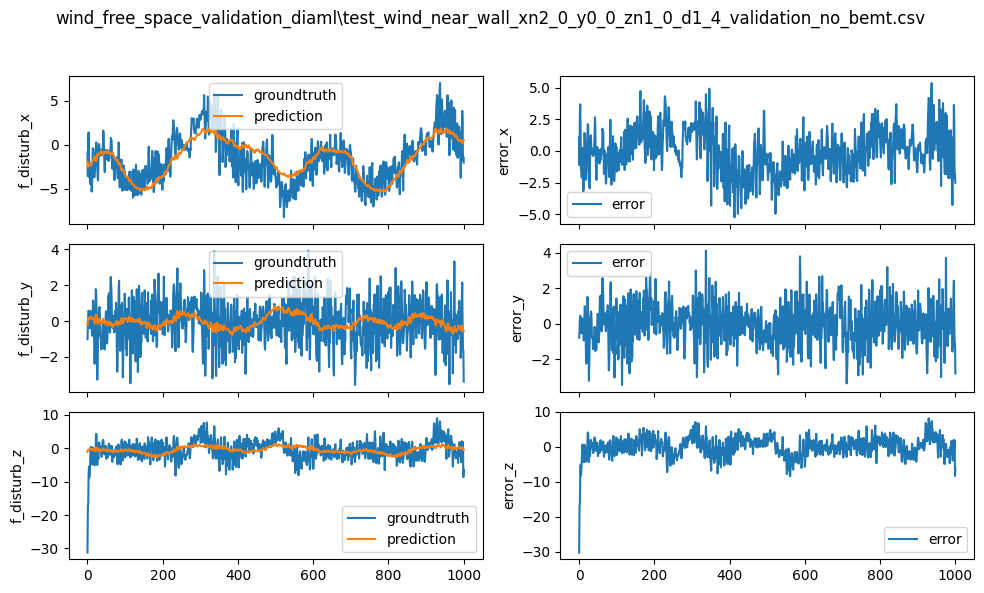

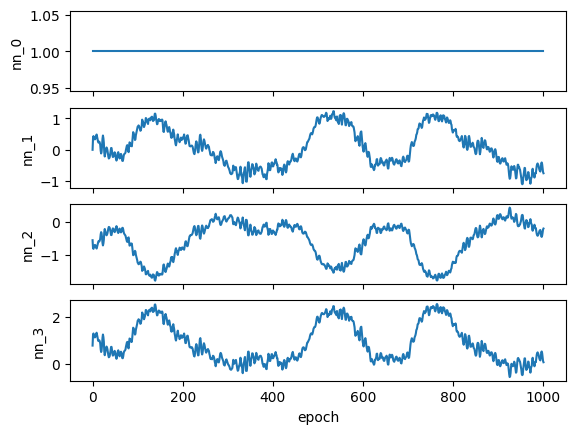

phi_out: tensor([[ 1.0000,  0.0033, -0.5563,  0.7829],
        [ 1.0000,  0.3488, -0.8075,  1.2355],
        [ 1.0000,  0.5170, -0.9289,  1.4543],
        ...,
        [ 1.0000, -0.4087, -0.5250,  0.5704],
        [ 1.0000, -0.5428, -0.4294,  0.3926],
        [ 1.0000, -0.6161, -0.3746,  0.2954]])
a = tensor([[ -8.5875,  -1.3244,   5.4685],
        [-15.9040,  -1.7231,   3.7776],
        [ 19.4346,   3.2040,  -1.6073],
        [ 22.1913,   3.7702,  -3.2013]])


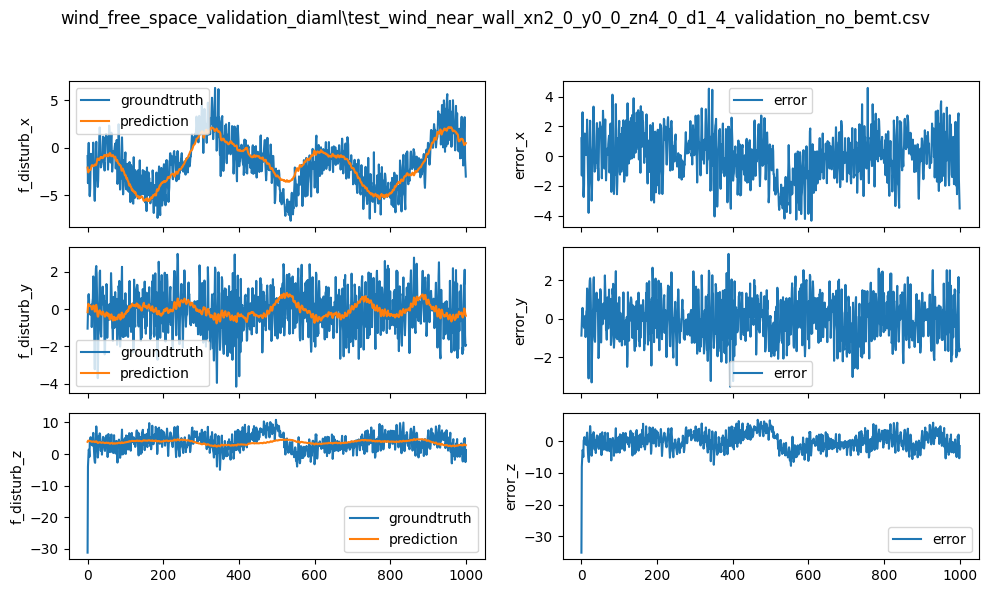

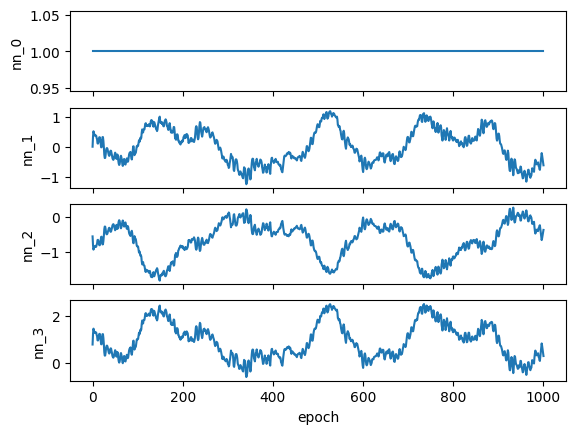

phi_out: tensor([[ 1.0000,  0.0096, -0.5595,  0.7894],
        [ 1.0000,  1.1875, -1.4431,  2.3345],
        [ 1.0000,  1.2229, -1.4323,  2.3548],
        ...,
        [ 1.0000,  0.6954, -1.4488,  2.4548],
        [ 1.0000,  0.7147, -1.4419,  2.4695],
        [ 1.0000,  0.6742, -1.4013,  2.4114]])
a = tensor([[ -7.1077,  -2.5497,  -2.1698],
        [ -3.5719,  -1.7436, -18.6137],
        [  5.1961,   2.9167,  18.8668],
        [  6.9992,   3.6489,  18.4858]])


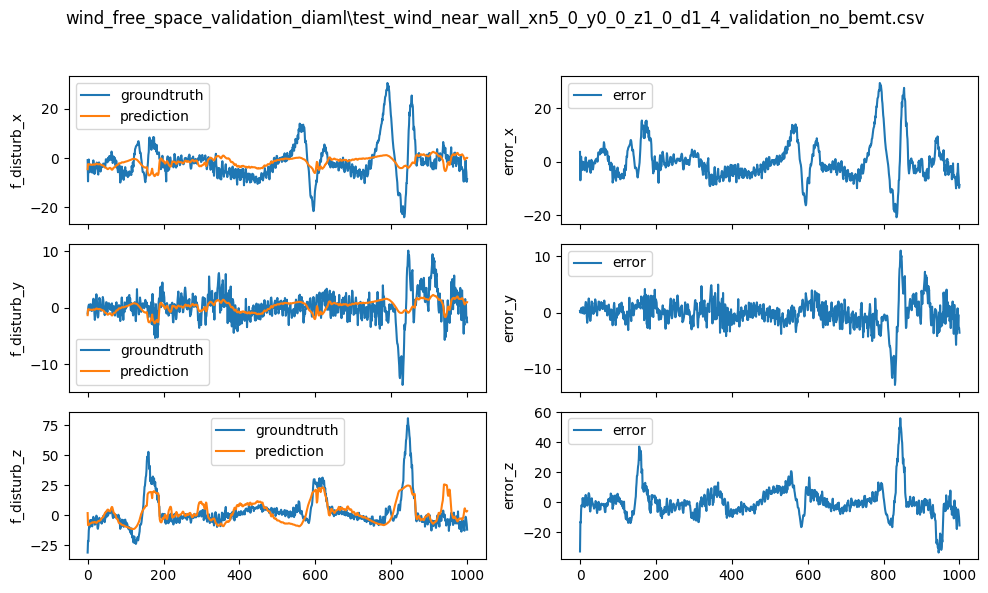

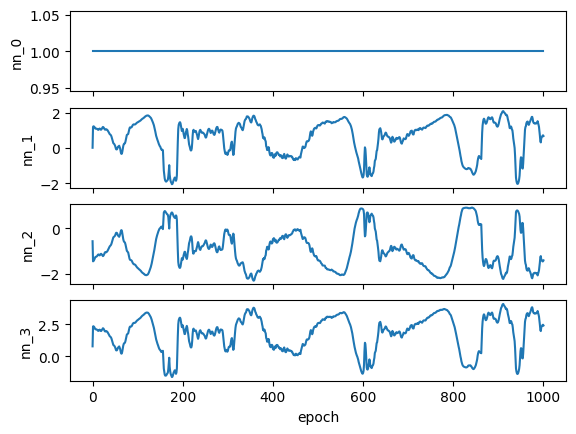

phi_out: tensor([[ 1.0000,  0.0034, -0.5559,  0.7810],
        [ 1.0000,  1.1489, -1.4018,  2.2683],
        [ 1.0000,  1.1900, -1.3896,  2.2907],
        ...,
        [ 1.0000, -0.2804, -0.4917,  0.9420],
        [ 1.0000, -0.7943, -0.1392,  0.2754],
        [ 1.0000, -1.3663,  0.2561, -0.4846]])
a = tensor([[-7.4387,  0.0574, -3.2905],
        [-5.6450,  2.1110,  4.5829],
        [ 6.2303,  2.2132,  1.1250],
        [ 8.2871,  0.5509, -3.6646]])


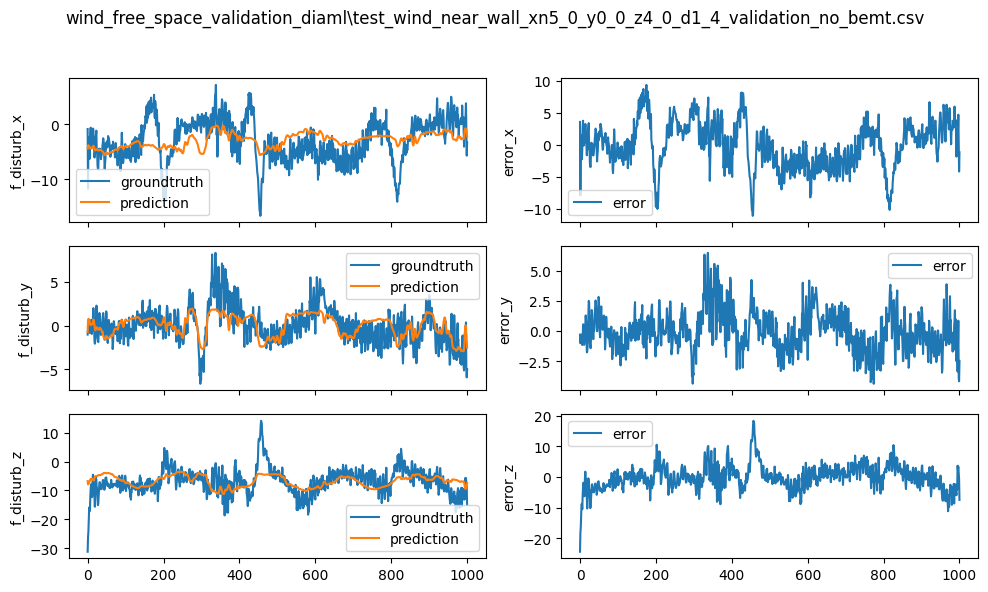

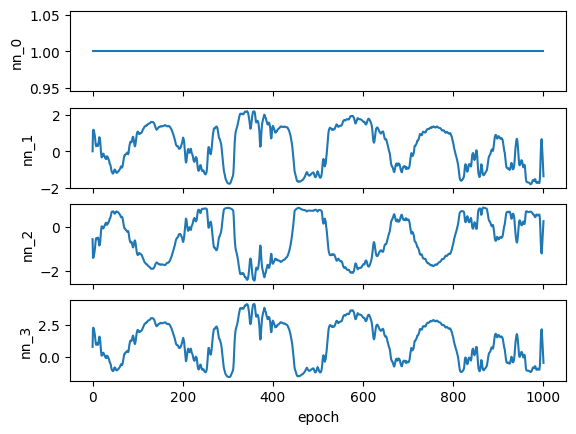

phi_out: tensor([[ 1.0000,  0.0104, -0.5599,  0.7910],
        [ 1.0000,  1.2002, -1.4629,  2.3636],
        [ 1.0000,  1.2480, -1.4737,  2.4118],
        ...,
        [ 1.0000,  0.4716, -1.2896,  2.1310],
        [ 1.0000,  0.3924, -1.2322,  2.0290],
        [ 1.0000,  0.3547, -1.2086,  1.9814]])
a = tensor([[-4.3189, -1.0622, 10.5260],
        [-4.0885, -0.4799, -5.7827],
        [ 6.4233,  1.2076, -5.6155],
        [ 5.7954,  1.4353, -6.1561]])


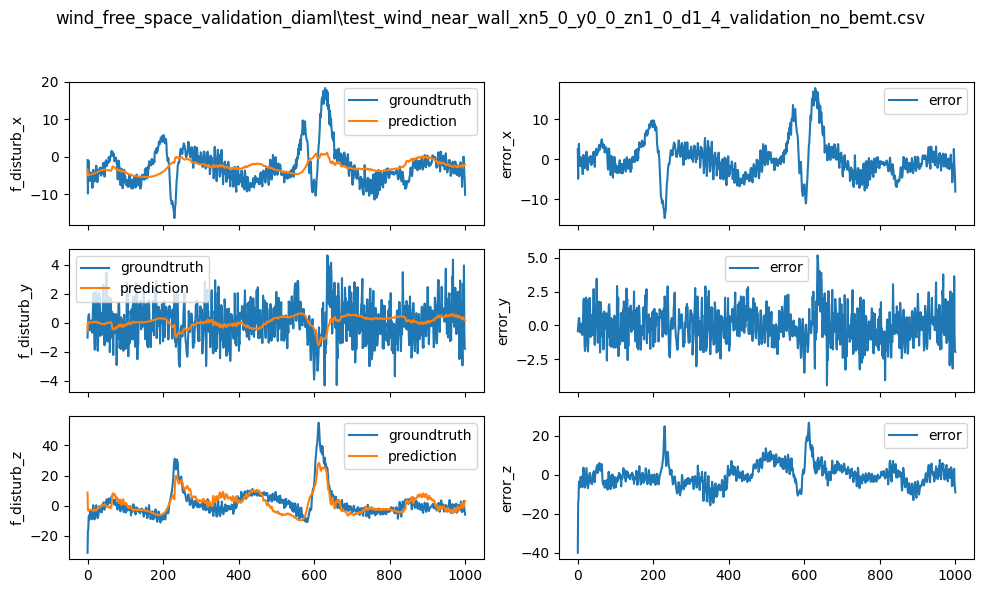

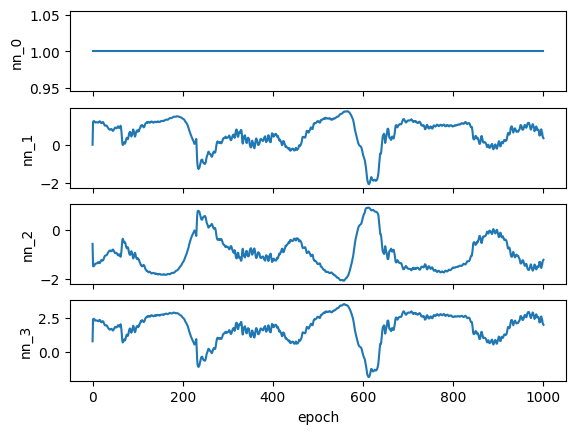

phi_out: tensor([[ 1.0000,  0.0105, -0.5598,  0.7918],
        [ 1.0000,  1.2057, -1.4946,  2.3993],
        [ 1.0000,  1.2876, -1.5591,  2.5193],
        ...,
        [ 1.0000, -0.0956, -1.0213,  1.4365],
        [ 1.0000, -0.1533, -0.9907,  1.3656],
        [ 1.0000, -0.2447, -0.9260,  1.2458]])
a = tensor([[  3.1398,   0.2945,  23.2375],
        [ -2.0635,   1.3675,   9.5206],
        [ 10.5390,   0.4120,  -1.4628],
        [  3.1263,  -0.3550, -14.8347]])


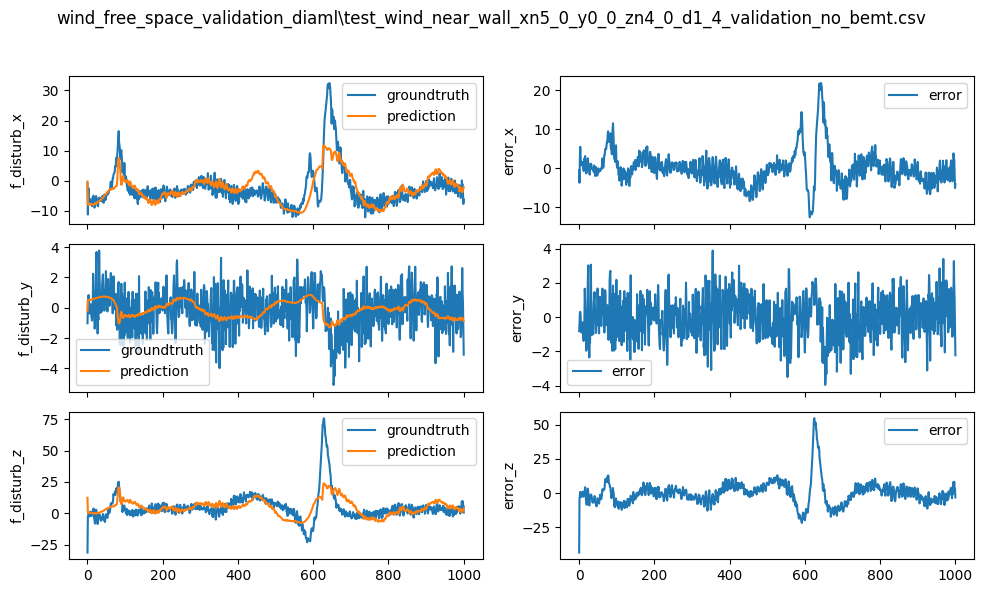

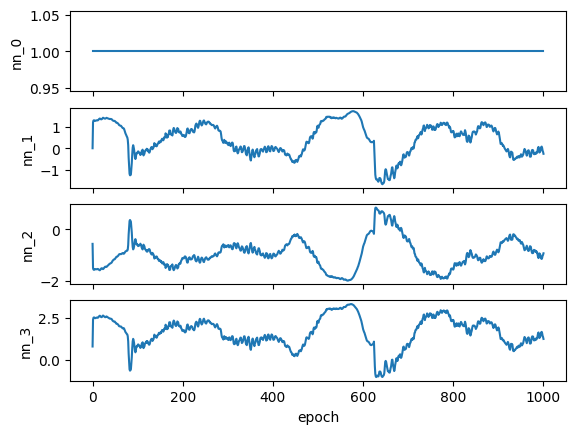

average rms for dim 0: 2.932313231475859
average rms for dim 1: 1.3883847851428384
average rms for dim 2: 4.588420615587178


c:\Users\jiexu\Documents\workspace\aerial_robot_testbed\learning\validator.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


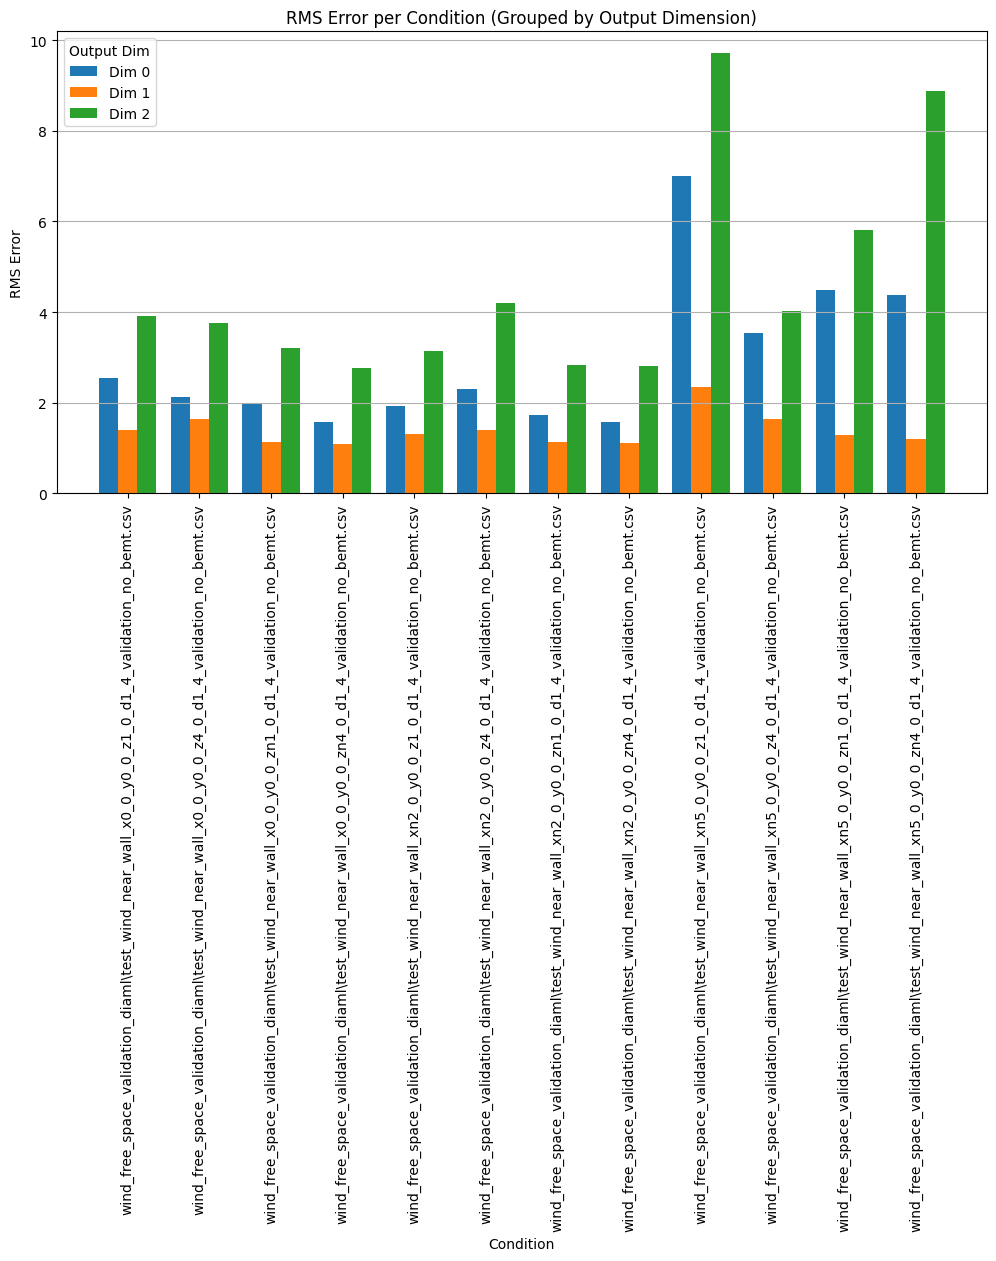

overall average mse after train: 39.25436638842119 before train: 74.09969683581448
average mse for dim 0: after train: 11.061651430904675 before train: 18.320760899004707
average mse for dim 1: after train: 2.0426423405664518 before train: 2.458485955368574
average mse for dim 2: after train: 26.15007261695006 before train: 53.32044998144121


c:\Users\jiexu\Documents\workspace\aerial_robot_testbed\learning\validator.py:120: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


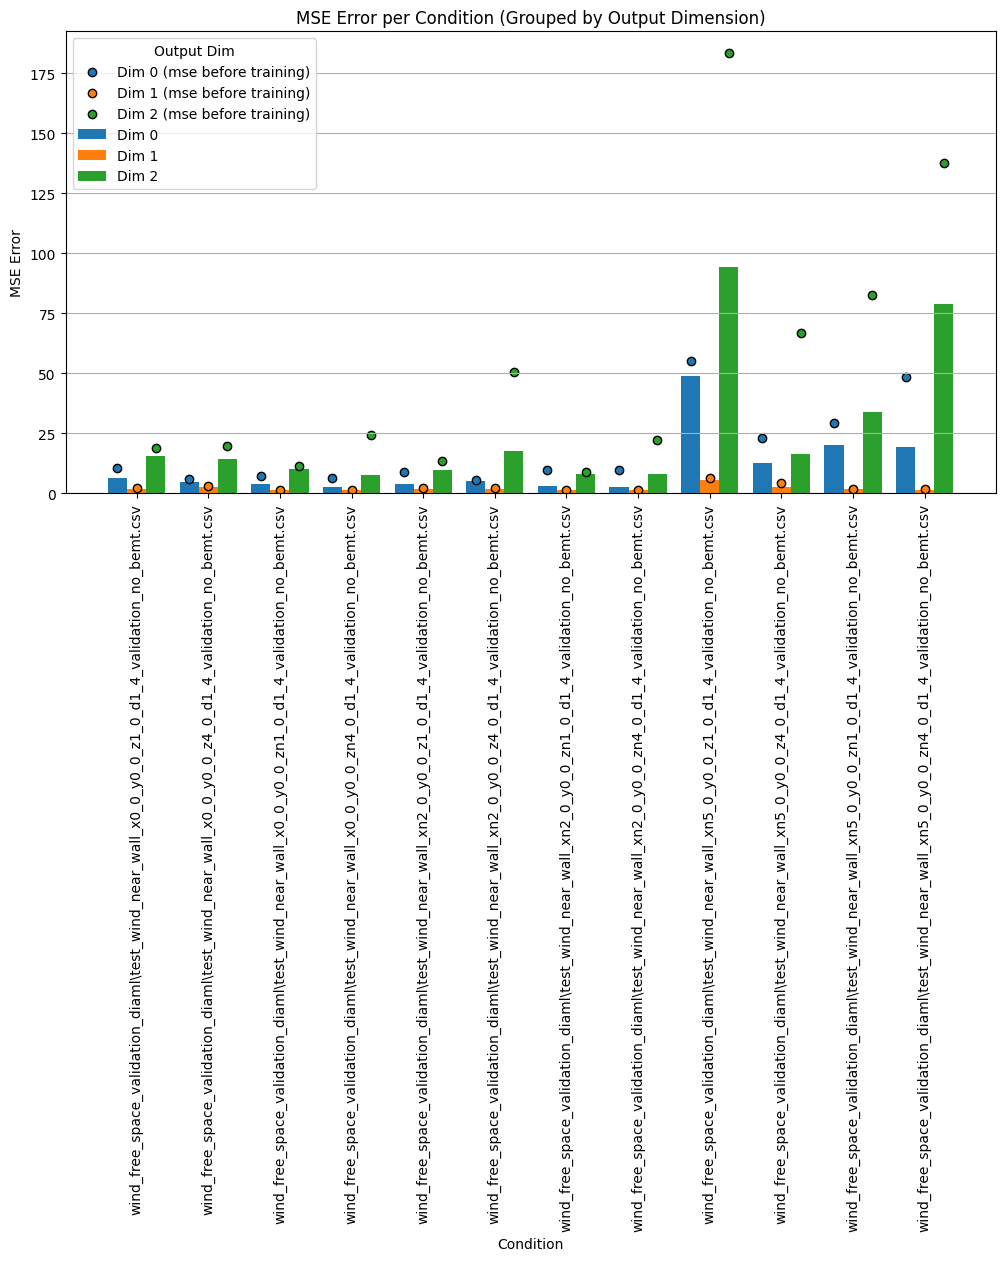

In [5]:
%matplotlib inline
model_name = training_subfolder

subfolder = validation_subfolder
subfolder = "wind_free_space_validation_diaml"
# subfolder = "nf_validation_back2back"
data_list = generate_data_list(subfolder)
print("test Data List:")
for data in data_list:
    print(data)

# debug
# data_list = data_list[:1]  # use small data list for quick testing

manager = factory.make_test_pipeline()

manager.set_up(
    data_menu=data_list,
    input_label_map_file=path1,
    model_name=model_name
)

# make a new trainer to replicate the above setup, just to allow verify_model to work
manager.test()
plt.show()  
